# Day 22: Media Content Genre SQL Ranker

**Industry:** Media / Entertainment  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · SQLite · SQL window functions · matplotlib · seaborn

**Data:** MovieLens Small Dataset — GroupLens Research, University of Minnesota  
9,742 movies · 100,836 ratings · 610 users

---

## Who uses this
A **streaming platform content team** deciding genre commissioning budget. Which genres get the highest ratings? Which have the most engaged audiences? Which are underserved relative to demand?

## What we build
1. Load MovieLens movies + ratings into SQLite
2. SQL window functions — rank genres by avg rating, volume, engagement
3. Genre performance scorecard
4. Decade analysis — which genres peaked when?
5. Content gap analysis — high demand, low supply
6. 4-panel seaborn dashboard
7. Export commissioning recommendation CSV

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load Data and Build SQLite

In [2]:
movies  = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

# Parse year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['decade'] = (movies['year'] // 10 * 10).astype('Int64')

# Explode genres — each movie gets one row per genre
movies_exploded = movies.assign(
    genre=movies['genres'].str.split('|')
).explode('genre').reset_index(drop=True)
movies_exploded = movies_exploded[movies_exploded['genre'] != '(no genres listed)']

# Convert timestamp to year
ratings['rating_year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year

# Load into SQLite
conn = sqlite3.connect('movielens.db')
movies.to_sql('movies', conn, if_exists='replace', index=False)
movies_exploded.to_sql('movies_genres', conn, if_exists='replace', index=False)
ratings.to_sql('ratings', conn, if_exists='replace', index=False)

print(f'Movies loaded:   {len(movies):,}')
print(f'Ratings loaded:  {len(ratings):,}')
print(f'Genre rows:      {len(movies_exploded):,}')
print(f'Unique genres:   {movies_exploded["genre"].nunique()}')
print(f'Year range:      {int(movies["year"].min())} – {int(movies["year"].max())}')
print(f'\nGenre list:')
print(sorted(movies_exploded['genre'].unique()))

Movies loaded:   9,742
Ratings loaded:  100,836
Genre rows:      22,050
Unique genres:   19
Year range:      1902 – 2018

Genre list:
['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


## Step 3 — SQL Window Functions: Genre Performance Scorecard

In [3]:
# Core genre performance query with window functions
genre_performance_sql = """
WITH genre_stats AS (
    SELECT
        mg.genre,
        COUNT(DISTINCT mg.movieId)          AS movie_count,
        COUNT(r.rating)                     AS total_ratings,
        ROUND(AVG(r.rating), 3)             AS avg_rating,
        ROUND(MIN(r.rating), 1)             AS min_rating,
        ROUND(MAX(r.rating), 1)             AS max_rating,
        COUNT(DISTINCT r.userId)            AS unique_raters,
        ROUND(CAST(COUNT(r.rating) AS FLOAT)
              / COUNT(DISTINCT mg.movieId), 1) AS ratings_per_movie
    FROM movies_genres mg
    LEFT JOIN ratings r ON mg.movieId = r.movieId
    GROUP BY mg.genre
    HAVING total_ratings > 100
),
ranked AS (
    SELECT *,
        RANK() OVER (ORDER BY avg_rating DESC)       AS rank_by_rating,
        RANK() OVER (ORDER BY total_ratings DESC)    AS rank_by_volume,
        RANK() OVER (ORDER BY ratings_per_movie DESC) AS rank_by_engagement,
        RANK() OVER (ORDER BY movie_count DESC)      AS rank_by_supply
    FROM genre_stats
)
SELECT *,
    ROUND((rank_by_rating + rank_by_volume + rank_by_engagement) / 3.0, 1) AS composite_rank
FROM ranked
ORDER BY composite_rank ASC
"""

genre_perf = pd.read_sql_query(genre_performance_sql, conn)

print('=== Genre Performance Scorecard (SQL Window Functions) ===')
print(genre_perf[['genre','movie_count','total_ratings','avg_rating',
                   'ratings_per_movie','rank_by_rating','rank_by_volume',
                   'rank_by_engagement','composite_rank']].to_string())

=== Genre Performance Scorecard (SQL Window Functions) ===
          genre  movie_count  total_ratings  avg_rating  ratings_per_movie  rank_by_rating  rank_by_volume  rank_by_engagement  composite_rank
0     Adventure         1263          24161       3.509               19.1              11               5                   2             6.0
1         Crime         1199          16681       3.658               13.9               4               8                   7             6.3
2         Drama         4361          41928       3.656                9.6               5               1                  17             7.7
3      Thriller         1894          26452       3.494               14.0              13               4                   6             7.7
4        Action         1828          30635       3.448               16.8              16               3                   4             7.7
5          IMAX          158           4145       3.618               26.2         

## Step 4 — Decade Analysis: Which genres peaked when?

In [4]:
decade_sql = """
SELECT
    mg.genre,
    m.decade,
    COUNT(DISTINCT mg.movieId)   AS movies,
    COUNT(r.rating)              AS ratings,
    ROUND(AVG(r.rating), 2)      AS avg_rating
FROM movies_genres mg
JOIN movies m ON mg.movieId = m.movieId
LEFT JOIN ratings r ON mg.movieId = r.movieId
WHERE m.decade >= 1980
  AND mg.genre NOT IN ('(no genres listed)')
GROUP BY mg.genre, m.decade
HAVING movies >= 5
ORDER BY mg.genre, m.decade
"""

decade_df = pd.read_sql_query(decade_sql, conn)

# Top genres by total movie count for pivot
top_genres = genre_perf.nlargest(10, 'movie_count')['genre'].tolist()
decade_pivot = (
    decade_df[decade_df['genre'].isin(top_genres)]
    .pivot_table(index='genre', columns='decade', values='movies', fill_value=0)
)

print('=== Movies per genre per decade (top 10 genres) ===')
print(decade_pivot.to_string())

=== Movies per genre per decade (top 10 genres) ===
decade      1980    1990    2000   2010
genre                                  
Action     227.0   392.0   549.0  464.0
Adventure  170.0   239.0   363.0  292.0
Comedy     492.0   890.0  1135.0  758.0
Crime      124.0   264.0   404.0  218.0
Drama      439.0  1038.0  1365.0  743.0
Fantasy    106.0   149.0   252.0  178.0
Horror     176.0   160.0   298.0  190.0
Romance    154.0   422.0   523.0  217.0
Sci-Fi     156.0   173.0   266.0  244.0
Thriller   180.0   420.0   654.0  417.0


## Step 5 — Content Gap Analysis

High demand (ratings per movie) but low supply (movie count) = commissioning opportunity.

In [5]:
gap_df = genre_perf.copy()
gap_df['demand_score'] = (
    (gap_df['ratings_per_movie'] - gap_df['ratings_per_movie'].min()) /
    (gap_df['ratings_per_movie'].max() - gap_df['ratings_per_movie'].min()) * 100
).round(1)
gap_df['supply_score'] = (
    (gap_df['movie_count'] - gap_df['movie_count'].min()) /
    (gap_df['movie_count'].max() - gap_df['movie_count'].min()) * 100
).round(1)
gap_df['opportunity_score'] = (gap_df['demand_score'] - gap_df['supply_score']).round(1)
gap_df = gap_df.sort_values('opportunity_score', ascending=False)

print('=== Content Gap Analysis ===')
print('(High opportunity = high demand relative to supply)')
print(gap_df[['genre','movie_count','ratings_per_movie',
              'demand_score','supply_score','opportunity_score']].to_string())

=== Content Gap Analysis ===
(High opportunity = high demand relative to supply)
          genre  movie_count  ratings_per_movie  demand_score  supply_score  opportunity_score
5          IMAX          158               26.2         100.0           1.7               98.3
6        Sci-Fi          980               17.6          63.2          20.9               42.3
0     Adventure         1263               19.1          69.7          27.5               42.2
9       Fantasy          779               15.2          53.0          16.2               36.8
16      Western          167               11.6          37.6           1.9               35.7
7           War          382               12.7          42.3           6.9               35.4
15      Musical          334               12.4          41.0           5.8               35.2
8       Mystery          573               13.4          45.3          11.4               33.9
12     Children          664               13.9          47.4   

## Step 6 — Visualise: 4-Panel Dashboard

Dashboard saved as genre_dashboard.png


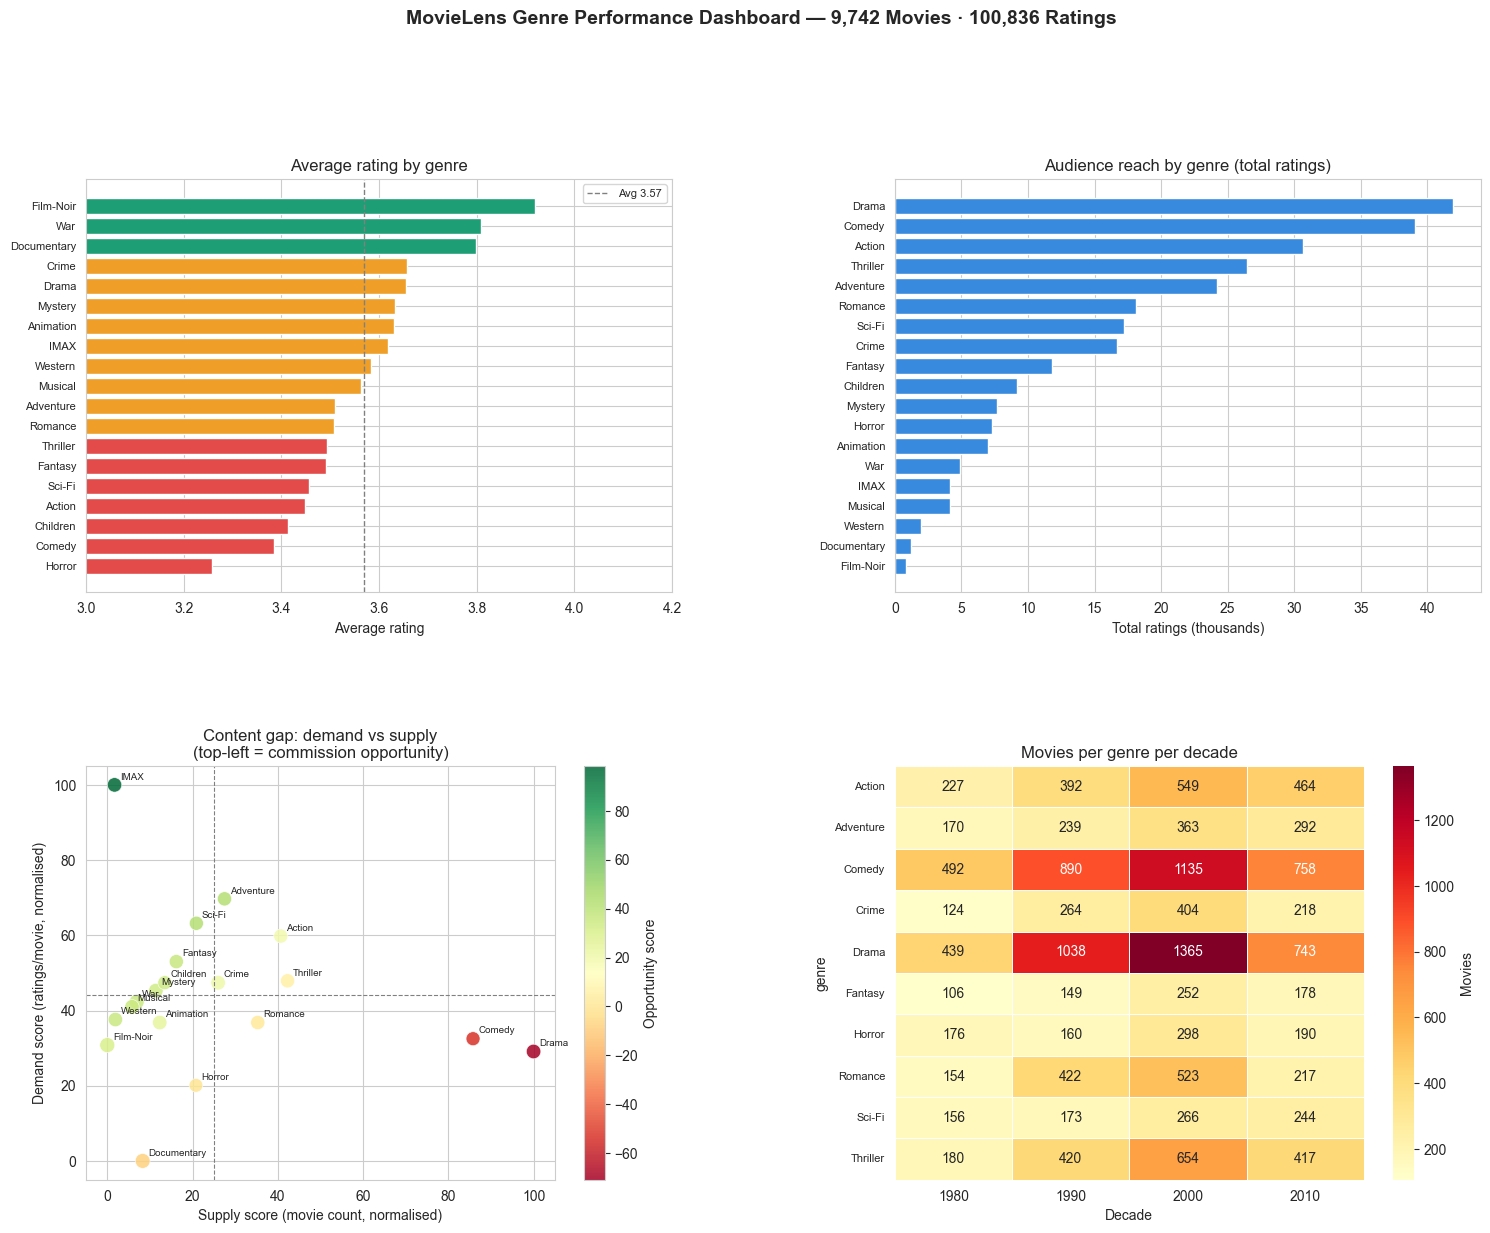

In [6]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle('MovieLens Genre Performance Dashboard — 9,742 Movies · 100,836 Ratings',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.38)

# Panel 1 — Avg rating by genre (sorted)
ax1 = fig.add_subplot(gs[0, 0])
gp_sorted = genre_perf.sort_values('avg_rating', ascending=True)
colors1 = ['#1D9E75' if r >= 3.7 else '#EF9F27' if r >= 3.5 else '#E24B4A'
           for r in gp_sorted['avg_rating']]
ax1.barh(gp_sorted['genre'], gp_sorted['avg_rating'], color=colors1)
ax1.axvline(genre_perf['avg_rating'].mean(), color='gray',
            linestyle='--', linewidth=1, label=f'Avg {genre_perf["avg_rating"].mean():.2f}')
ax1.set_xlabel('Average rating')
ax1.set_title('Average rating by genre')
ax1.legend(fontsize=8)
ax1.set_xlim(3.0, 4.2)
ax1.tick_params(axis='y', labelsize=8)

# Panel 2 — Total ratings (audience reach) by genre
ax2 = fig.add_subplot(gs[0, 1])
gp_vol = genre_perf.sort_values('total_ratings', ascending=True)
ax2.barh(gp_vol['genre'], gp_vol['total_ratings'] / 1000, color='#378ADD')
ax2.set_xlabel('Total ratings (thousands)')
ax2.set_title('Audience reach by genre (total ratings)')
ax2.tick_params(axis='y', labelsize=8)

# Panel 3 — Content gap: demand vs supply scatter
ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(gap_df['supply_score'], gap_df['demand_score'],
                      s=gap_df['avg_rating'] * 30,
                      c=gap_df['opportunity_score'], cmap='RdYlGn',
                      alpha=0.85, edgecolors='white', linewidth=0.5)
for _, row in gap_df.iterrows():
    ax3.annotate(row['genre'],
                 (row['supply_score'], row['demand_score']),
                 fontsize=7, xytext=(4, 4), textcoords='offset points')
avg_sup = gap_df['supply_score'].mean()
avg_dem = gap_df['demand_score'].mean()
ax3.axvline(avg_sup, color='gray', linestyle='--', linewidth=0.8)
ax3.axhline(avg_dem, color='gray', linestyle='--', linewidth=0.8)
ax3.set_xlabel('Supply score (movie count, normalised)')
ax3.set_ylabel('Demand score (ratings/movie, normalised)')
ax3.set_title('Content gap: demand vs supply\n(top-left = commission opportunity)')
plt.colorbar(scatter, ax=ax3, label='Opportunity score')

# Panel 4 — Genre production by decade (heatmap)
ax4 = fig.add_subplot(gs[1, 1])
pivot_plot = decade_pivot.loc[
    decade_pivot.index.isin(top_genres[:10]),
    [c for c in decade_pivot.columns if c >= 1980]
]
sns.heatmap(pivot_plot.astype(int), ax=ax4, cmap='YlOrRd', annot=True,
            fmt='d', linewidths=0.5, cbar_kws={'label': 'Movies'})
ax4.set_title('Movies per genre per decade')
ax4.set_xlabel('Decade')
ax4.tick_params(axis='y', labelsize=8)

plt.savefig('genre_dashboard.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as genre_dashboard.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [7]:
os.makedirs('output', exist_ok=True)

genre_perf.to_csv('output/genre_scorecard.csv', index=False)
gap_df.to_csv('output/content_gap_analysis.csv', index=False)
decade_df.to_csv('output/decade_analysis.csv', index=False)

# Top and bottom performers
top5_rating  = genre_perf.nlargest(5, 'avg_rating')
top5_volume  = genre_perf.nlargest(5, 'total_ratings')
top5_engage  = genre_perf.nlargest(5, 'ratings_per_movie')
top5_gap     = gap_df.nlargest(5, 'opportunity_score')
worst5       = genre_perf.nsmallest(5, 'avg_rating')

conn.close()

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Movies analysed:           {len(movies):,}')
print(f'Ratings analysed:          {len(ratings):,}')
print(f'Unique genres:             {movies_exploded["genre"].nunique()}')
print(f'Year range:                {int(movies["year"].min())} – {int(movies["year"].max())}')
print()
print('TOP 5 BY AVG RATING:')
for _, row in top5_rating.iterrows():
    print(f'  {row["genre"]:20s}: {row["avg_rating"]:.3f} ({row["total_ratings"]:,} ratings)')
print()
print('TOP 5 BY AUDIENCE REACH (total ratings):')
for _, row in top5_volume.iterrows():
    print(f'  {row["genre"]:20s}: {row["total_ratings"]:,} ratings ({row["movie_count"]} movies)')
print()
print('TOP 5 BY ENGAGEMENT (ratings per movie):')
for _, row in top5_engage.iterrows():
    print(f'  {row["genre"]:20s}: {row["ratings_per_movie"]:.1f} ratings/movie')
print()
print('TOP 5 COMMISSIONING OPPORTUNITIES (high demand, low supply):')
for _, row in top5_gap.iterrows():
    print(f'  {row["genre"]:20s}: opportunity score {row["opportunity_score"]:+.1f}')
print()
print('LOWEST RATED GENRES:')
for _, row in worst5.iterrows():
    print(f'  {row["genre"]:20s}: {row["avg_rating"]:.3f}')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Movies analysed:           9,742
Ratings analysed:          100,836
Unique genres:             19
Year range:                1902 – 2018

TOP 5 BY AVG RATING:
  Film-Noir           : 3.920 (870 ratings)
  War                 : 3.808 (4,859 ratings)
  Documentary         : 3.798 (1,219 ratings)
  Crime               : 3.658 (16,681 ratings)
  Drama               : 3.656 (41,928 ratings)

TOP 5 BY AUDIENCE REACH (total ratings):
  Drama               : 41,928 ratings (4361 movies)
  Comedy              : 39,053 ratings (3756 movies)
  Action              : 30,635 ratings (1828 movies)
  Thriller            : 26,452 ratings (1894 movies)
  Adventure           : 24,161 ratings (1263 movies)

TOP 5 BY ENGAGEMENT (ratings per movie):
  IMAX                : 26.2 ratings/movie
  Adventure           : 19.1 ratings/movie
  Sci-Fi              : 17.6 ratings/movie
  Action              : 16.8 ratings/movie
  Fantasy             : 15.2 ratings/movie

TOP 5 COMMISSIONING O